<a href="https://colab.research.google.com/github/jeank29/S100_Analitica_de_datos_UTP_Jean/blob/main/S100_PS1_Jimenez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Set 1 — ¿Qué distingue a un género musical?

**S100 · Introducción a la Ciencia de Datos** · Maestría en Analítica de Datos, UTP
**Prof. Gabriel Soto, M.Sc.** · II Semestre 2026

**Modalidad:** individual · **Datos:** `spotify_songs.csv` (32,833 canciones)

---

## El caso

Una plataforma de streaming quiere entender **en qué se diferencian los géneros musicales**
según las características de audio de sus canciones. Te pasan la tabla completa y cinco
preguntas que van de lo general a lo específico.

Los cinco ejercicios están **encadenados**: cada uno usa resultados del anterior. Resuélvelos
en orden y no borres las variables que vayas creando.

---

## Instrucciones de entrega

**1 · Trabaja sobre este cuaderno.** Escribe tu código en las celdas marcadas y tus respuestas
escritas en las celdas de texto que dicen *Tu respuesta*. El cuaderno debe **correr de principio
a fin sin errores** (Kernel → Restart & Run All antes de entregar).

**2 · Sube el cuaderno a tu repositorio de GitHub.**

- Crea (o usa) un repositorio para el curso, por ejemplo `S100-analitica-datos`.
- Súbelo con el nombre `S100_PS1_TuApellido.ipynb`.
- El repositorio debe ser **público** (o darme acceso). Si no puedo abrirlo, no puedo calificarlo.
- El historial de commits debe mostrar tu trabajo: haz varios commits, no uno solo al final.

**3 · Envía por correo ÚNICAMENTE el enlace a GitHub.**

- Correo: **gabriel.soto@utp.ac.pa**
- Asunto: `S100 - Problem Set 1 - TuNombre`
- En el cuerpo va **solo el enlace** al repositorio (o al cuaderno dentro del repositorio).
- **No adjuntes archivos.** Los correos con el cuaderno adjunto y sin enlace no se califican.

**4 · Registra tu enlace en la lista del curso.**

- Abre el archivo **`S100 Lista Estudiantes Provisional`**, ubicado en el **SharePoint del curso**,
  carpeta **`01_administracion`**.
- Agrega el enlace de tu repositorio de GitHub **en la fila que corresponde a tu nombre**.
- Este paso es parte de la entrega: sin el enlace en la lista, la entrega se considera incompleta.

> **Sobre el uso de IA.** Está permitido, con una condición: que puedas explicar lo que
> entregaste. En la última celda del cuaderno indica en qué ejercicios la usaste y qué hace ese
> código. No hay penalización por usarla; sí la hay por entregar código que no sabes leer.

## Calificación

| Ejercicio | Qué se evalúa | Puntos |
|---|---|---|
| 1 | Exploración inicial correcta y completa | 15 |
| 2 | Resumen numérico + histograma bien etiquetado | 15 |
| 3 | Comparación por género + gráfico que se entiende solo | 20 |
| 4 | Matriz de correlación, identificación de pares, interpretación | 25 |
| 5 | Correlación por grupo, estandarización y conclusión escrita | 25 |

Los gráficos sin **título** y sin **etiquetas de eje con unidad** pierden puntos, siempre.


In [ ]:
from google.colab import files
uploaded = files.upload() #Subida del archivo spotify

Saving spotify_songs.csv to spotify_songs.csv


---
## Paso 0 · Preparación

Ejecuta esta celda. No hay que escribir nada aquí.

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

AZUL = "#13294B"
plt.rcParams.update({"figure.figsize": (8, 4.2), "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "axes.axisbelow": True,
                     "grid.color": "#D3D8E0", "axes.titleweight": "bold", "font.size": 10})

df = pd.read_csv("spotify_songs.csv")

# La duración viene en milisegundos: la pasamos a minutos, que sí se puede interpretar.
df["duration_min"] = df["duration_ms"] / 60000

# Las 10 variables de audio con las que vamos a trabajar todo el problem set.
audio = ["danceability", "energy", "loudness", "speechiness", "acousticness",
         "instrumentalness", "liveness", "valence", "tempo", "duration_min"]

print("Filas y columnas:", df.shape)

Filas y columnas: (32833, 24)


### Diccionario de las columnas que vas a usar

| Columna | Qué es |
|---|---|
| `track_name`, `track_artist` | Nombre de la canción y del artista |
| `track_popularity` | Popularidad de 0 a 100 |
| `playlist_genre` | Género: pop, rap, rock, latin, r&b, edm |
| `danceability`, `energy`, `valence`, `acousticness`, `instrumentalness`, `liveness`, `speechiness` | Índices de 0 a 1 |
| `loudness` | Volumen medio en decibeles (negativo) |
| `tempo` | Pulsos por minuto (BPM) |
| `duration_min` | Duración en minutos (la creamos arriba) |


---
# Ejercicio 1 · Conocer los datos antes de calcular nada
**Dificultad: baja** · 15 puntos

Antes de responder cualquier pregunta hay que saber qué hay en la tabla. Haz estas cuatro cosas:

**a)** Muestra las **primeras filas** de `df`.

**b)** Saca el **resumen estadístico** de las columnas numéricas.

**c)** Cuenta **cuántas canciones hay de cada género** (`playlist_genre`).

**d)** Cuenta **cuántos valores faltan** en cada columna.

> 💡 **Pistas.** `df.head()` · `df.describe()` · `df["columna"].value_counts()` · `df.isna().sum()`
> Para ver solo las columnas donde sí falta algo: guarda el resultado en una variable `faltan` y
> filtra con `faltan[faltan > 0]`.

In [ ]:
# a) Primeras filas
print(df.head())

# b) Resumen estadístico
print(df.describe())

# c) Canciones por género
print(df["playlist_genre"].value_counts())

# d) Valores faltantes
faltan = df.isna().sum()
print(faltan[faltan > 0])

                 track_id                                         track_name  \
0  6f807x0ima9a1j3VPbc7VN  I Don't Care (with Justin Bieber) - Loud Luxur...   
1  0r7CVbZTWZgbTCYdfa2P31                    Memories - Dillon Francis Remix   
2  1z1Hg7Vb0AhHDiEmnDE79l                    All the Time - Don Diablo Remix   
3  75FpbthrwQmzHlBJLuGdC7                  Call You Mine - Keanu Silva Remix   
4  1e8PAfcKUYoKkxPhrHqw4x            Someone You Loved - Future Humans Remix   

       track_artist  track_popularity          track_album_id  \
0        Ed Sheeran                66  2oCs0DGTsRO98Gh5ZSl2Cx   
1          Maroon 5                67  63rPSO264uRjW1X5E6cWv6   
2      Zara Larsson                70  1HoSmj2eLcsrR0vE9gThr4   
3  The Chainsmokers                60  1nqYsOef1yKKuGOVchbsk6   
4     Lewis Capaldi                69  7m7vv9wlQ4i0LFuJiE2zsQ   

                                    track_album_name track_album_release_date  \
0  I Don't Care (with Justin Bieber) [Loud Luxu

### 📝 Tu respuesta — Ejercicio 1

**1.** ¿Los seis géneros tienen más o menos la misma cantidad de canciones, o hay alguno
   muy por encima o por debajo? ¿Por qué importa eso antes de comparar promedios entre géneros?

>Los seis géneros tienen cantidades de canciones bastante parecidas. EDM es el que más tiene, con 6,043 canciones, mientras que rock es el que menos, con 4,951.
>Aunque existe una diferencia, no parece ser lo suficientemente grande como para que un género domine los resultados solamente por tener más datos.
>Esto importa porque, al comparar los promedios, es mejor que los géneros tengan tamaños de muestra similares.
>Si uno tuviera muy pocas canciones, sus resultados podrían verse más afectados por valores atípicos y sería más difícil determinar si la diferencia en los promedios realmente se debe al género.
>Por eso, esta distribución permite hacer una comparación más justa entre los seis géneros.

**2.** Mira la fila `min` y la fila `max` de `duration_min` en el `describe()`. ¿Hay algún valor
   que te haga sospechar de un error de captura? Explica en una frase.

>Sí, el rango es amplio: la canción más corta dura 0.07 minutos (4 segundos), posiblemente por un error en los datos, mientras que la más larga dura 8.6 minutos, una duración razonable para una canción extendida.

---
# Ejercicio 2 · Resumir una variable
**Dificultad: baja** · 15 puntos

Del Ejercicio 1 ya sabes qué contiene la tabla. Ahora nos concentramos en **una sola variable:
`energy`**, que va a ser el hilo conductor del resto del problem set.

**a)** Calcula de `energy`: **media**, **mediana**, **desviación estándar** y **rango**
(el rango es el máximo menos el mínimo).

**b)** Haz un **histograma** de `energy` con 30 barras. Debe llevar **título** y **etiquetas de eje**.

**c)** Calcula el `skew()` de `energy`.

> 💡 **Pistas.** Los resúmenes son métodos: `df["energy"].mean()`, `.median()`, `.std()`,
> `.max()`, `.min()`, `.skew()`.
> Para el histograma: `plt.hist(df["energy"], bins=30, color=AZUL, edgecolor="white")` y luego
> `plt.xlabel(...)`, `plt.ylabel(...)`, `plt.title(...)`, `plt.show()`.
> Recuerda: skew cerca de 0 = simétrica; positivo = cola a la derecha; negativo = cola a la izquierda.

Media: 0.6986 Mediana:0.7210 Desviación estándar:0.1809 Rango:0.9998


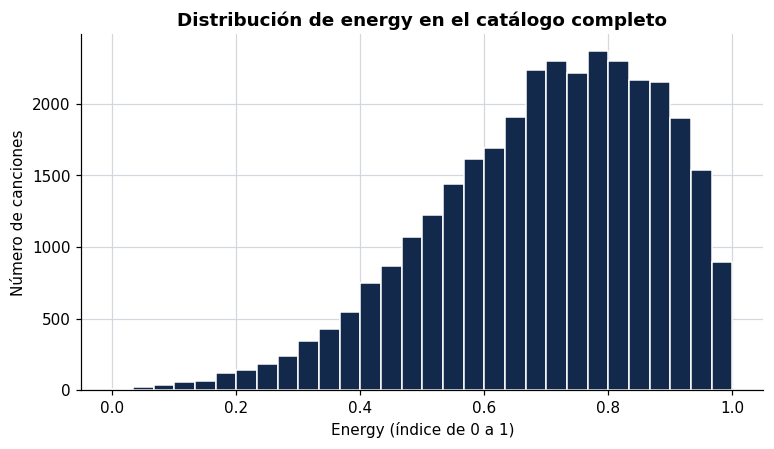

Skew: -0.6363


In [ ]:
# a) Media, mediana, desviación estándar y rango de energy
media = df["energy"].mean()
mediana = df["energy"].median()
desv = df["energy"].std()
rango = df["energy"].max() - df["energy"].min()
print(f"Media: {media:.4f} Mediana:{mediana:.4f} Desviación estándar:{desv:.4f} Rango:{rango:.4f}")


# b) Histograma
plt.hist(df["energy"], bins=30, color=AZUL, edgecolor="white")
plt.xlabel("Energy (índice de 0 a 1)")
plt.ylabel("Número de canciones")
plt.title("Distribución de energy en el catálogo completo")
plt.show()

# c) Asimetría
skew = df["energy"].skew()
print(f"Skew: {skew:.4f}")


### 📝 Tu respuesta — Ejercicio 2

**1.** Escribe los cuatro números de (a) en una frase.

>La variable energy, que representa la energía de las canciones, tiene un promedio de 0.70, una mediana de 0.72 y una desviación estándar de 0.18, con valores que van de 0 a casi 1 (rango ≈ 1.00).

**2.** ¿La media quedó por encima o por debajo de la mediana? ¿Hacia qué lado está la cola?
   ¿Coincide eso con el signo del `skew()` y con lo que ves en el histograma?

>La media de energy (0.70) es menor que la mediana (0.72), lo que indica una ligera asimetría hacia la izquierda, confirmada por el skew negativo (-0.64).
>Esto significa que la mayoría de las canciones tienen valores altos de energy (0.6–0.9), mientras que una menor cantidad se concentra en valores bajos.

---
# Ejercicio 3 · ¿En qué se diferencian los géneros?
**Dificultad: baja** · 20 puntos

Ya sabes cómo se reparte `energy` en toda la tabla. La pregunta ahora es si **esa repartición es
la misma dentro de cada género**.

**a)** Calcula la **media** y la **desviación estándar** de `energy` **por género**, en una sola tabla.
Ordénala de mayor a menor por la media y guárdala en una variable llamada `energia_genero`
(la vas a volver a usar en el Ejercicio 5).

**b)** Haz un **gráfico de barras horizontales** con la media de `energy` por género.
Ordenado por valor, con título y etiqueta de eje.

**c)** Haz un **boxplot** de `energy` por género.

> 💡 **Pistas.**
> `df.groupby("playlist_genre")["energy"].agg(["mean", "std"])` da las dos columnas de una vez;
> después `.sort_values("mean", ascending=False)`.
> Barras horizontales: `plt.barh(serie.index, serie.values, color=AZUL)` — ordena la serie de
> **menor a mayor** para que la barra más larga quede arriba.
> Boxplot: `df.boxplot(column="energy", by="playlist_genre")`, o armando la lista de grupos
> como hicimos en el laboratorio de la Clase 3.
>
> ⚠️ "Más enérgico" y "más disperso" son preguntas distintas: la primera la contesta la media,
> la segunda la desviación estándar. No asumas que van juntas.

                    mean       std
playlist_genre                    
edm             0.802476  0.139415
rock            0.732813  0.194501
latin           0.708312  0.152308
pop             0.701028  0.171084
rap             0.650708  0.170340
r&b             0.590934  0.179407


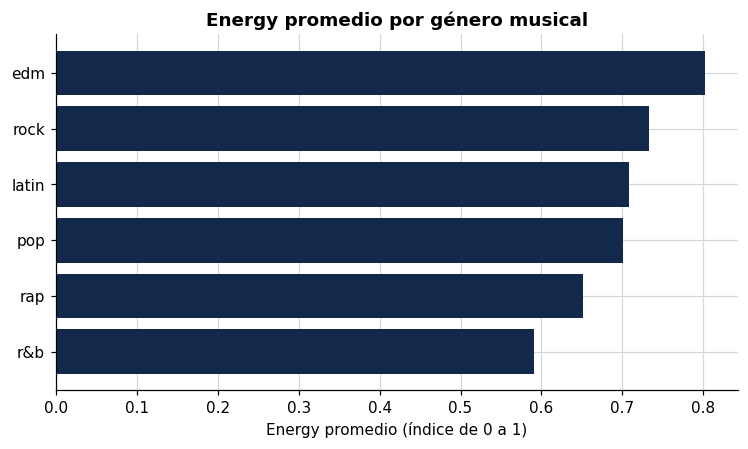

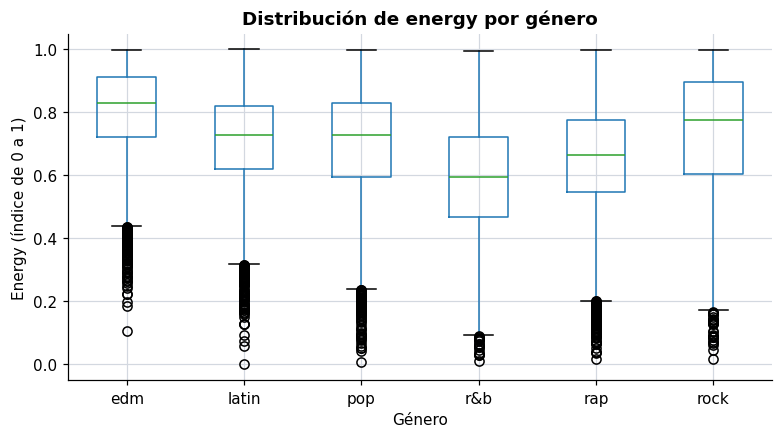

In [ ]:
# a) Media y desviación de energy por género
energia_genero = df.groupby("playlist_genre")["energy"].agg(["mean", "std"]).sort_values("mean", ascending=False)
print(energia_genero)

# b) Gráfico de barras horizontales
serie = energia_genero["mean"].sort_values()
plt.barh(serie.index, serie.values, color=AZUL)
plt.xlabel("Energy promedio (índice de 0 a 1)")
plt.title("Energy promedio por género musical")
plt.show()

# c) Boxplot
df.boxplot(column="energy", by="playlist_genre")
plt.xlabel("Género")
plt.ylabel("Energy (índice de 0 a 1)")
plt.title("Distribución de energy por género")
plt.suptitle("")
plt.show()


### 📝 Tu respuesta — Ejercicio 3

**1.** ¿Cuál es el género **más enérgico** en promedio y cuál el **menos**? Da los dos números.

> El género más enérgico en promedio es edm, con una energy media de 0.80. El menos enérgico es
> r&b, con una energy media de 0.59.

**2.** ¿Cuál es el género **más disperso** (mayor desviación estándar)? ¿Es el mismo que el más
   enérgico? ¿Qué significa, en palabras, que un género tenga mucha dispersión en `energy`?

> El género más disperso es rock, con una desviación estándar de 0.19 — no es el mismo que el
> más enérgico (edm tiene una desviación de apenas 0.14, de las más bajas). Que rock tenga mucha
> dispersión significa que dentro de ese género hay mucha variedad: conviven canciones muy
> tranquilas con canciones muy intensas, mientras que en edm casi todas las canciones son
> consistentemente enérgicas, con poca variación entre ellas.

**3.** Tapa el código y mira solo tu gráfico de barras. ¿Lo pondrías en un informe sin escribir
   un párrafo explicándolo? Si no, arréglalo antes de seguir.

>El gráfico de barras presenta de forma clara y autónoma los resultados, ya que incluye un título, etiquetas con sus respectivas unidades y los géneros ordenados de mayor a menor energy, facilitando la comparación entre ellos sin necesidad de consultar información adicional.

---
# Ejercicio 4 · Buscar relaciones entre variables
**Dificultad: media** · 25 puntos

Hasta aquí miraste variables **una por una**. Ahora las miramos **de a dos**: ¿cuáles se mueven
juntas?

**a)** Calcula la **matriz de correlación** de las 10 variables de la lista `audio`.

**b)** Conviértela en una lista ordenada de pares y encuentra el par **más positivo** y el
**más negativo**. Ojo con dos cosas antes de ordenar:
- la **diagonal** (toda variable correlaciona 1 consigo misma) hay que quitarla;
- la matriz es **simétrica**, así que cada par aparece dos veces: quédate con una sola copia.
Si lo haces bien, tu lista debe tener **45 pares**, no 90.

**c)** Grafica el par **más positivo** con un diagrama de dispersión.
Con 32,833 puntos la nube se vuelve una mancha: usa una muestra y transparencia.

**d)** Calcula ahora la correlación de cada variable de `audio` con `track_popularity`.
¿Cuál es la que más se relaciona con la popularidad?

> 💡 **Pistas.**
> `corr = df[audio].corr()`
> ```python
> pares = corr.unstack()
> pares = pares[pares < 0.999]                                       # fuera la diagonal
> pares = pares[pares.index.get_level_values(0) < pares.index.get_level_values(1)]  # fuera repetidos
> pares = pares.sort_values()
> ```
> El primero y el último de esa lista son los que buscas.
> Para el gráfico: `m = df.sample(4000, random_state=1)` y luego
> `plt.scatter(m["x"], m["y"], s=6, alpha=0.25, color=AZUL, lw=0)`.
> Para (d): `df[audio + ["track_popularity"]].corr()["track_popularity"].sort_values()`.

                  danceability  energy  loudness  speechiness  acousticness  \
danceability              1.00   -0.09      0.03         0.18         -0.02   
energy                   -0.09    1.00      0.68        -0.03         -0.54   
loudness                  0.03    0.68      1.00         0.01         -0.36   
speechiness               0.18   -0.03      0.01         1.00          0.03   
acousticness             -0.02   -0.54     -0.36         0.03          1.00   
instrumentalness         -0.01    0.03     -0.15        -0.10         -0.01   
liveness                 -0.12    0.16      0.08         0.06         -0.08   
valence                   0.33    0.15      0.05         0.06         -0.02   
tempo                    -0.18    0.15      0.09         0.04         -0.11   
duration_min             -0.10    0.01     -0.12        -0.09         -0.08   

                  instrumentalness  liveness  valence  tempo  duration_min  
danceability                 -0.01     -0.12     0.33

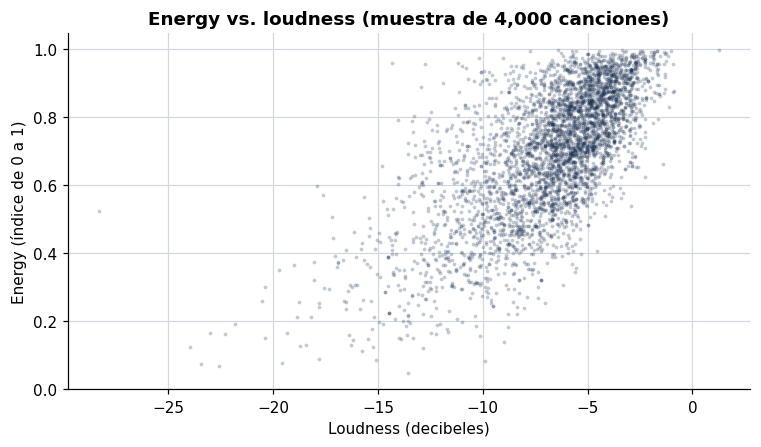

instrumentalness   -0.149872
duration_min       -0.143682
energy             -0.109112
liveness           -0.054584
tempo              -0.005378
speechiness         0.006819
valence             0.033231
loudness            0.057687
danceability        0.064748
acousticness        0.085159
track_popularity    1.000000
Name: track_popularity, dtype: float64


In [ ]:
# a) Matriz de correlación
corr = df[audio].corr()
print(corr.round(2))

# b) Lista de pares ordenada: el más positivo y el más negativo
pares = corr.unstack()
pares = pares[pares < 0.999]
pares = pares[pares.index.get_level_values(0) < pares.index.get_level_values(1)] # Quita los pares duplicados (energy-loudness y loudness-energy son el mismo par repetido)
pares = pares.sort_values()
print("Número de pares:", len(pares))
print("\nMás negativo:\n", pares.head(1))
print("\nMás positivo:\n", pares.tail(1))

# c) Diagrama de dispersión del par más positivo
m = df.sample(4000, random_state=1)
plt.scatter(m["loudness"], m["energy"], s=6, alpha=0.25, color=AZUL, lw=0)
plt.xlabel("Loudness (decibeles)")
plt.ylabel("Energy (índice de 0 a 1)")
plt.title("Energy vs. loudness (muestra de 4,000 canciones)")
plt.show()

# d) Correlación de cada variable de audio con track_popularity
corr_popularidad = df[audio + ["track_popularity"]].corr()["track_popularity"].sort_values()
print(corr_popularidad)

### 📝 Tu respuesta — Ejercicio 4

**1.** ¿Cuál es el par con la correlación **positiva** más fuerte y cuál con la **negativa** más
   fuerte? Da los dos valores de r.

>La correlación positiva más fuerte se observa entre energy y loudness (r = 0.68), lo que indica que las canciones con mayor intensidad sonora tienden a presentar valores más altos de energy.
>Por otro lado, acousticness y energy muestran la correlación negativa más fuerte (r = -0.54), lo que sugiere que las canciones más acústicas tienden a tener menores niveles de energy.

**2.** Mira tu diagrama de dispersión. La correlación es alta, pero la nube **no** es una línea.
   ¿Qué te dice eso sobre lo que r puede y no puede predecir para **una** canción concreta?

>Aunque existe una tendencia positiva entre loudness y energy, la dispersión de los datos indica que esta relación no es exacta. Por lo tanto, el valor de r describe el comportamiento general del conjunto, pero loudness por sí solo no permite predecir con precisión el nivel de energy de una canción individual.

**3.** Escribe **una frase de veredicto** sobre el par más positivo: ¿se puede afirmar que una
   variable **causa** a la otra? Antes de responder descarta las tres alternativas que vimos en
   clase: una **variable oculta** que mueva a las dos, la **causa invertida**, o la **coincidencia**.

> No se puede afirmar causalidad a partir de esta correlación: es plausible que exista una
> variable oculta (el estilo de producción o el género de la canción) que empuje a la vez tanto
> el loudness como la energy hacia arriba, sin que una cause directamente a la otra; la
> coincidencia es poco probable dado el tamaño de la muestra, pero la causa invertida (que la
> energy "cause" el loudness en el sentido de mezcla de audio) tampoco puede descartarse solo
> con este número.

**4.** De las 10 variables de audio, ¿cuál correlaciona más con `track_popularity`? ¿Es una
   relación fuerte o débil? ¿Te sirve ese número solo para predecir si una canción será popular?

> La variable que más correlaciona (en valor absoluto) con track_popularity es instrumentalness
> (r ≈ -0.15), seguida de duration_min (r ≈ -0.14). Es una relación muy débil: ninguna variable
> de audio por sí sola explica de forma importante qué tan popular es una canción, así que este
> número no sirve para predecir con confianza la popularidad de una canción individual usando
> solo sus características de audio.

---
# Ejercicio 5 · La relación escondida
**Dificultad: media** · 25 puntos

En el Ejercicio 4 calculaste correlaciones sobre **toda la tabla**. Pero en el Ejercicio 3
comprobaste que los géneros son muy distintos entre sí. La pregunta final del problem set es qué
pasa cuando juntas las dos cosas.

Trabaja con el par **`energy` y `danceability`**.

**a)** Calcula la correlación entre `energy` y `danceability` **en el conjunto completo**.

**b)** Calcula **esa misma correlación dentro de cada género**. Arma una tabla con los seis
valores, ordenada, y guárdala en `corr_genero`.

**c)** Junta en una sola tabla, para cada género: la **media de energy** (la tienes en
`energia_genero`, del Ejercicio 3), la **media de `danceability`**, la **media de
`track_popularity`** y la **correlación** de (b).

**d)** Estandariza `energy` creando la columna `energy_z`, y encuentra la canción con el
**z más alto**. Muestra su nombre, artista, género, `energy` y `energy_z`.
Comprueba además que `energy_z` tiene media 0 y desviación 1, y que su `skew()` es el mismo
que el de `energy` original.

> 💡 **Pistas.**
> Correlación por grupo:
> `df.groupby("playlist_genre").apply(lambda g: g["energy"].corr(g["danceability"])).sort_values()`
> El `lambda g:` recibe el sub-DataFrame de cada género.
> Para juntar tablas que comparten el mismo índice (el género): `pd.concat([tabla1, tabla2], axis=1)`.
> Estandarización: `z = (x - x.mean()) / x.std()`.
> `.idxmax()` devuelve el **índice** de la fila con el valor máximo; con `df.loc[idx, [...]]`
> sacas las columnas que quieras de esa fila.
>
> ⚠️ Antes de escribir la conclusión, mira los **signos** de la tabla de (b): ¿todos los géneros
> apuntan hacia el mismo lado?

In [ ]:
# a) Correlación global entre energy y danceability
r_global = df["energy"].corr(df["danceability"])
print(f"Correlación global energy-danceability: {r_global:.4f}")

# b) La misma correlación dentro de cada género
# Calcula la correlación entre energy y danceability, pero por separado dentro de cada género
corr_genero = df.groupby("playlist_genre").apply(lambda g: g["energy"].corr(g["danceability"])).sort_values()
print(corr_genero)

# c) Tabla resumen por género
tabla_resumen = pd.concat([
    energia_genero["mean"].rename("energy_media"),
    df.groupby("playlist_genre")["danceability"].mean().rename("danceability_media"),
    df.groupby("playlist_genre")["track_popularity"].mean().rename("popularidad_media"),
    corr_genero.rename("corr_energy_danceability")
], axis=1)
print(tabla_resumen)

# d) Estandarización de energy y canción más extrema
# Estandariza energy: dice cuántas desviaciones estándar está cada canción por encima/debajo del promedio
df["energy_z"] = (df["energy"] - df["energy"].mean()) / df["energy"].std()
# Busca la posición (no el valor) de la canción con el energy_z más alto
idx_max = df["energy_z"].idxmax()
print(df.loc[idx_max, ["track_name", "track_artist", "playlist_genre", "energy", "energy_z"]])

print("\nComprobación:")
print("Media de energy_z:", df["energy_z"].mean())
print("Desv. estándar de energy_z:", df["energy_z"].std())
print("Skew de energy_z:", df["energy_z"].skew(), " | Skew de energy original:", df["energy"].skew())

Correlación global energy-danceability: -0.0861
playlist_genre
rock    -0.152882
edm     -0.150262
rap     -0.148173
pop     -0.030729
latin    0.115939
r&b      0.159201
dtype: float64
                energy_media  danceability_media  popularidad_media  \
playlist_genre                                                        
edm                 0.802476            0.655041          34.833526   
rock                0.732813            0.520548          41.728338   
latin               0.708312            0.713287          47.026576   
pop                 0.701028            0.639302          47.744870   
rap                 0.650708            0.718353          43.215454   
r&b                 0.590934            0.670179          41.223532   

                corr_energy_danceability  
playlist_genre                            
edm                            -0.150262  
rock                           -0.152882  
latin                           0.115939  
pop                           

/tmp/ipykernel_1598/168562157.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  corr_genero = df.groupby("playlist_genre").apply(lambda g: g["energy"].corr(g["danceability"])).sort_values()


### 📝 Tu respuesta — Ejercicio 5

**1.** ¿Cuánto vale r en el conjunto completo? ¿Cuál es el género con el r **más negativo** y
   cuál con el **más positivo**? Da los tres números.

>En el conjunto completo, r = -0.09, lo que indica una correlación prácticamente nula. Por género, rock presenta la correlación más negativa (r = -0.15), mientras que r&b presenta la más positiva (r = 0.16).

**2.** Si el r global es cercano a cero, ¿se puede concluir que `energy` y `danceability`
   no tienen ninguna relación? Explica qué está pasando por debajo del promedio global.
   ¿Cuál es la "tercera variable" de la que hablamos en la lámina de correlación y causalidad?

>No, sería incorrecto concluir que no existe relación. Aunque la correlación global es cercana a cero, al analizar los géneros por separado se observan relaciones en direcciones opuestas: en rock, edm y rap es negativa, mientras que en latin y r&b es positiva. Esto indica que playlist_genre influye en la relación entre energy y danceability, haciendo que los efectos se contrarresten al combinar todos los géneros. Este fenómeno se conoce como paradoja de Simpson.

**3.** Mira la tabla de (c) junto con lo que sacaste en el Ejercicio 4(d). ¿El género con la
   energía media más alta es también el más popular? ¿Qué le dirías a la plataforma de streaming
   si te pidiera "subirle la energía a las canciones para que sean más populares"?

>No. Los datos no muestran que una mayor energy esté relacionada con una mayor track_popularity. Por ejemplo, edm presenta la energía promedio más alta (0.80), pero tiene una popularidad promedio de solo 34.8, mientras que pop, con una energía más moderada (0.70), alcanza la mayor popularidad promedio (47.7). Además, la correlación entre energy y track_popularity es negativa (r ≈ -0.11). Por lo tanto, no sería adecuado recomendar aumentar la energy como estrategia para lograr mayor popularidad, ya que esta puede estar influenciada por otros factores como el artista, el género, el marketing o la época.

**4.** La canción con el `energy_z` más alto: ¿qué tan lejos de la media está, en desviaciones
   estándar? ¿Por qué el `skew()` de `energy_z` es idéntico al de `energy`, si le restamos la
   media y la dividimos entre la desviación?

> La canción con el energy_z más alto está a 1.67 desviaciones estándar por encima de la media.
> El skew de energy_z es idéntico al de energy original porque estandarizar (restar la media y
> dividir entre la desviación estándar) es una transformación lineal: cambia la escala y el
> punto de referencia de los datos, pero no cambia la forma de la distribución. La asimetría es
> una propiedad de la forma, no de la escala, así que se mantiene exactamente igual antes y
> después de estandarizar.

---
# Cierre · El entregable escrito

Escribe **un párrafo de 4 a 6 frases** dirigido a alguien que **no tomó este curso** —el gerente
de producto de la plataforma de streaming— con el hallazgo principal del problem set.

Requisitos:

1. Empieza por el **hallazgo**, no por el método.
2. Usa **al menos tres números** de los que calculaste, indicando de qué ejercicio salen.
3. **Sin jerga**: nada de "r", "desviación estándar" ni "skew" sin traducir a español común.
4. Cierra con **una advertencia**: algo que estos datos **NO** permiten concluir.

> 💡 "r = 0.06" no es una frase. "En el conjunto completo parece que no hay relación, pero es
> porque dos géneros se comportan al revés y se cancelan entre sí" sí lo es.

### 📝 Tu párrafo

>**Hallazgo:** Las canciones con mayor energy no necesariamente son las más populares. Por ejemplo, EDM es el género con mayor energía promedio, pero tiene una popularidad menor que pop, que presenta una energía más moderada.
>Esto sugiere que tener más energía no garantiza que una canción tenga mayor éxito.

>También observamos que la relación entre energy y danceability cambia según el género.
>En algunos, como rock, las canciones más enérgicas tienden a ser menos bailables, mientras que en otros, como r&b, ocurre lo contrario.
>Por eso, es importante considerar el género al interpretar estas características.

>**Advertencia:** Estos resultados muestran tendencias generales, pero no permiten asegurar que aumentar la energy hará que una canción sea más popular ni que una canción específica tendrá éxito por sus características de audio.


---

### 🤖 Uso de IA

¿En qué ejercicios usaste IA? Para cada uno, explica **qué hace ese código** o **qué alternativa
pensaste antes de preguntar**.

>


---

### ✅ Antes de entregar, verifica:

- [ ] Kernel → Restart & Run All: el cuaderno corre de principio a fin **sin errores**.
- [ ] Todos los gráficos tienen **título** y **etiquetas de eje con unidad**.
- [ ] Todas las celdas de *Tu respuesta* están contestadas.
- [ ] El cuaderno está en **GitHub** con el nombre `S100_PS1_TuApellido.ipynb`.
- [ ] Envié el **enlace** (y solo el enlace) a gabriel.soto@utp.ac.pa.
- [ ] Agregué el enlace en `S100 Lista Estudiantes Provisional`, carpeta `01_administracion`
      del SharePoint, junto a mi nombre.